[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/christov_2010_stokes1_second_grade.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to regenerate, from scratch, the three correct representations of the solution of Stokes' first problem for a second-grade fluid collected by [Christov (2010)](https://arxiv.org/abs/1009.4416) (Fourier sine transform; Laplace transform with the Bromwich integral; Laplace transform with quotient splitting). Furthermore, you will be able to show that they agree with each other and with a finite-difference solution, reproduce Fig. 1 of that paper, and see the common erroneous solution fail. (A companion notebook does the same for the Oldroyd-B fluid.)

Unlike the Comments reproduced in the other notebooks, Christov (2010) is mostly about what is right: it collects the correct representations, derived by different methods, of the one solution against which the erroneous ones are checked, and it explains the start-up jump that every correct solution must have.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.integrate import quad
from scipy.special import erfc, i0e
from scipy.linalg import solve_banded
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](https://christov.tmnt-lab.org), Purdue University.

Reproducing results of I. C. Christov.

# THE PROBLEM

The initial-boundary-value problem (IBVP), Eq. (13) of Christov (2010), for the velocity $u(y,t)$ of a second-grade fluid above a plate suddenly moved with velocity $U_0$:
\begin{align*}
    \frac{\partial u}{\partial t} &= \nu \frac{\partial^2 u}{\partial y^2} + \alpha \frac{\partial^3 u}{\partial y\partial t\partial y}, & (y,t)\in(0,\infty)\times(0,\infty),\\
    u(0,t) &= U_0H(t),\qquad u \to 0 \;\;\text{as}\;\; y\to\infty, & t>0,\\
    u(y,0) &= 0, & y>0,
\end{align*}
where $H(t)$ is the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function), $\nu = \mu_0/\varrho_0$ and $\alpha = \alpha_1/\varrho_0$. With the dimensionless variables of Sect. 3.1 of the paper,
$$
    \tilde t = \frac{t\nu}{\alpha},\qquad \tilde y = \frac{y}{\sqrt{\alpha}},\qquad \tilde u = \frac{u}{U_0},
$$
the problem has no parameters; below, $\nu = \alpha = U_0 = 1$, so that $\tilde t = t$ and $\tilde y = y$. Fig. 1 of the paper shows $\tilde t = 1$ and $10$.

Note that the $H(t)$ in the boundary condition is not a triviality, because for this problem $\lim_{t\to0^+}u(y,t) \ne 0 = u(y,0)$: the _start-up jump_. The initial and boundary data are _incompatible_ at the corner $(y,t) = (0,0)$: $u(y,0) \to 0$ as $y\to0^+$, while $u(0,t) = U_0$ for $t > 0$. For a second-grade fluid, the Laplace transform below gives $\bar{u} \sim (U_0/s)\,\mathrm{e}^{-y/\sqrt{\alpha}}$ as $s\to\infty$, so that $u(y,0^+) = U_0\mathrm{e}^{-y/\sqrt{\alpha}}$: the mixed derivative responds instantly, and the fluid within a distance of order $\sqrt{\alpha}$ of the plate is set in motion at once. Its physical significance is explained by [Jordan (2010)](https://doi.org/10.1016/j.nonrwa.2009.01.010).

In [2]:
# Generic helpers, used by the erroneous solution below and by the correct ones
def sine_integral(g, y, t, nu, alpha):
    """Integral of g(xi, t, nu, alpha)*sin(xi*y) over 0 < xi < infinity."""
    # ordinary quadrature on (0, 1), then a Fourier-weighted rule for the slowly decaying tail
    head = quad(lambda xi: g(xi, t, nu, alpha)*np.sin(xi*y), 0, 1, limit=200)[0]
    tail = quad(g, 1, np.inf, args=(t, nu, alpha), weight='sin', wvar=y, limlst=100)[0]
    return head + tail

def g_decay(xi, t, nu, alpha):
    """exp(-nu xi^2 t/(1 + alpha xi^2))/xi."""
    return np.exp(-nu*xi**2*t/(1 + alpha*xi**2))/xi

# THE ERRONEOUS SOLUTION

> &#x26A0;&#xFE0F; **ERRONEOUS SOLUTION, reproduced as printed** in Eq. (2.6) of Fetec&#259;u & Zierep (2001) ([doi:10.1007/BF01178551](https://doi.org/10.1007/BF01178551)), p. 136, one of the solutions obtained by "dropping the $\tilde U(t)\delta(t)$ term" (Sect. 2.1 of Christov (2010)). It is shown below to be wrong.

$$
    u(y,t) = U_0\left[1 - \frac{2}{\pi}\int_0^\infty \frac{\sin(y\xi)}{\xi}\,\mathrm{e}^{-\frac{\nu\xi^2}{1+\alpha\xi^2}t}\,\mathrm{d}\xi\right].
$$

In [3]:
# WRONG, as printed: Eq. (2.6) of Fetecau & Zierep (2001)
def wrong_fetecau_zierep_26(y, t, nu=1.0, alpha=1.0):
    """Erroneous solution, as printed: Eq. (2.6) of Fetecau & Zierep (2001), with U0 = 1."""
    if y == 0:
        # the formula gives 1 at y = 0 exactly, but its limit as y -> 0+ is 1 - exp(-nu t/alpha):
        # Eq. (2.6) is discontinuous at the wall, which is the point of this notebook
        return 1.0
    return 1 - 2/np.pi*sine_integral(g_decay, y, t, nu, alpha)

> &#x26A0;&#xFE0F; **END OF THE ERRONEOUS SOLUTION.** The cells below are correct.

# THE CORRECT SOLUTION

**Representation 1** ([Christov & Christov, 2010](https://arxiv.org/abs/1003.2188)), by the Fourier sine transform in $y$ and the [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) in $t$, Eq. (14) of Christov (2010):
$$
    u(y,t) = U_0H(t)\left[1-\frac{2}{\pi}\int_{0}^{\infty}\frac{\sin(\xi y)}{\xi} \exp\left(\frac{-\nu \xi^2t}{1+\alpha\xi^2}\right)\,\mathrm{d}\xi+ \frac{2\alpha}{\pi}\int_{0}^{\infty}\frac{\xi \sin(\xi y)}{1+\alpha\xi^2}\exp\left(\frac{-\nu \xi^2 t}{1+\alpha\xi^2}\right)\,\mathrm{d}\xi\right].
$$

In [4]:
# Eq. (14) of Christov (2010): Fourier sine transform representation
def g_second(xi, t, nu, alpha):
    """xi/(1 + alpha xi^2) exp(-nu xi^2 t/(1 + alpha xi^2)), the integrand of the second integral of Eq. (14)."""
    return xi/(1 + alpha*xi**2)*np.exp(-nu*xi**2*t/(1 + alpha*xi**2))

def unsteadyv(y, t, nu=1.0, alpha=1.0):
    """Correct solution, Eq. (14) of Christov (2010), with U0 = 1, at one point y > 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    return 1 - 2/np.pi*sine_integral(g_decay, y, t, nu, alpha) + 2*alpha/np.pi*sine_integral(g_second, y, t, nu, alpha)

**Representation 2** ([Puri, 1984](https://doi.org/10.1007/BF01329198)), by the Laplace transform and the Bromwich integral, Eq. (15) of Christov (2010):
$$
    u(y,t)=U_0H(t)\left[1-\frac{1}{\pi}\int_{0}^{\alpha^{-1}}\mathrm{e}^{-\eta \nu t} \sin\left( \frac{y}{\sqrt{\alpha}}\sqrt{\frac{\eta}{\alpha^{-1}-\eta}}\,\right)\frac{\mathrm{d}\eta}{\eta}\right].
$$
Eq. (14) becomes Eq. (15) under the substitution $\eta=\xi^2/(1+\alpha\xi^2)$ (correcting the misprint in the published text after Eq. (15), which reads $\eta=\xi^2/(1+\alpha^2\xi^2)$). The next cell checks with SymPy that this substitution turns the argument of the sine in Eq. (15) into $\xi y$ and the exponent into $-\nu\xi^2 t/(1+\alpha\xi^2)$, while the printed one does not; it should print $\xi y$, the exponent, and a different expression for the printed substitution.

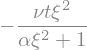

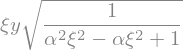

In [5]:
# Substitution between Eqs. (14) and (15) of Christov (2010)
xi, nu_s, alpha_s, y_s, t_s = sp.symbols('xi nu alpha y t', positive=True)
eta = xi**2/(1 + alpha_s*xi**2)
eta_printed = xi**2/(1 + alpha_s**2*xi**2)
display(sp.simplify(y_s/sp.sqrt(alpha_s)*sp.sqrt(eta/(1/alpha_s - eta))))
display(sp.simplify(-eta*nu_s*t_s))
display(sp.simplify(y_s/sp.sqrt(alpha_s)*sp.sqrt(eta_printed/(1/alpha_s - eta_printed))))

In [6]:
# Eq. (15) of Christov (2010): Puri's representation
def puri_15(y, t, nu=1.0, alpha=1.0):
    """Eq. (15) of Christov (2010) (Puri, 1984), with U0 = 1, at one point y > 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    integral = quad(lambda eta: np.exp(-eta*nu*t)*np.sin(y/np.sqrt(alpha)*np.sqrt(eta/(1/alpha - eta)))/eta,
                    0, 1/alpha, limit=2000)[0]
    return 1 - integral/np.pi

**Representation 3** (Bandelli _et al._, 1995), by the Laplace transform and the quotient splitting of [Morrison (1956)](https://doi.org/10.1090/qam/78848), Eq. (16) of Christov (2010), with $I_0$ the [modified Bessel function](https://en.wikipedia.org/wiki/Bessel_function#Modified_Bessel_functions) and $\mathrm{erfc}$ the complementary error function:
$$
    u(y,t) = U_0H(t) \left[ \mathrm{e}^{-t(\nu/\alpha)}\int_0^\infty \mathrm{e}^{-\zeta} I_0\left(2\sqrt{\zeta t(\nu/\alpha)} \right)\mathrm{erfc}\left(\frac{y}{2\sqrt{\alpha}\sqrt{\zeta}} \right)\,\mathrm{d}\zeta \right].
$$

In [7]:
# Eq. (16) of Christov (2010): representation of Bandelli et al. (1995)
def bandelli_16(y, t, nu=1.0, alpha=1.0):
    """Eq. (16) of Christov (2010) (Bandelli et al., 1995), with U0 = 1, at one point y > 0."""
    a = t*nu/alpha
    # exp(-a) exp(-z) I0(2 sqrt(z a)) = i0e(2 sqrt(z a)) exp(-(sqrt(z) - sqrt(a))^2), which does not overflow
    return quad(lambda z: i0e(2*np.sqrt(z*a))*np.exp(-(np.sqrt(z) - np.sqrt(a))**2)*erfc(y/(2*np.sqrt(alpha)*np.sqrt(z))),
                0, np.inf, limit=400)[0]

def profile(func, y, t):
    """Evaluate a point-wise solution func(y, t) on an array of y > 0."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = func(y[j], t)
    return u

Why are three integrals that look so different the same function? Because each is an exact inversion of one and the same Laplace-domain solution, $\bar{u}(y,s)$ of the next section: Eq. (15) by the Bromwich integral, Eq. (16) by splitting the quotient as in Morrison (1956), and Eq. (14) by way of the Fourier sine transform, which the substitution checked above takes into Eq. (15). The checks below confirm that they agree. The Laplace transform _always_ works on a well-posed linear IBVP: since $\mathcal{L}\{H(t)\} = 1/s$ and the initial condition is imposed at $t = 0^-$, the start-up is built in, and there is no distributional derivative of the Heaviside function to be taken (and so none to be dropped), as there is when the Fourier sine transform meets the mixed derivative. Puri's Eq. (15) remains the _first correct exact_ solution to this problem.

# AN INDEPENDENT CHECK

Two independent checks. First, the Laplace transform in $t$ of the IBVP gives
$$
    \bar{u}(y,s) = \frac{U_0}{s}\exp\left(-y\sqrt{\frac{s}{\nu+\alpha s}}\right),
$$
inverted numerically by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html). The next cell checks with SymPy that $\bar{u}$ solves $s\bar{u} = (\nu+\alpha s)\,\partial^2\bar{u}/\partial y^2$ with $\bar{u}(0,s) = U_0/s$; it should print two zeros.

In [8]:
# Laplace-domain solution of Eq. (13) of Christov (2010)
s, U0 = sp.symbols('s U_0', positive=True)
ubar_sym = U0/s*sp.exp(-y_s*sp.sqrt(s/(nu_s + alpha_s*s)))
(sp.simplify(s*ubar_sym - (nu_s + alpha_s*s)*ubar_sym.diff(y_s, 2)), sp.simplify(ubar_sym.subs(y_s, 0) - U0/s))

In [9]:
# Laplace-domain solution of Eq. (13) of Christov (2010), inverted by de Hoog's algorithm
def ubar_mp(s, y, nu=1.0, alpha=1.0):
    """Laplace-domain solution, with U0 = 1, in mpmath arithmetic."""
    return mp.exp(-y*mp.sqrt(s/(nu + alpha*s)))/s

def dehoog_inverse(y, t):
    """Laplace-domain solution inverted by mpmath's de Hoog algorithm, point by point in y (nu = alpha = 1)."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = float(mp.invertlaplace(lambda s: ubar_mp(s, y[j]), t, method='dehoog'))
    return u

Second, the finite-difference scheme, Eq. (21) of Christov (2010),
$$
    \delta_{t+}\mathfrak{u}^{n}_j = \nu \delta_{y+}\delta_{y-}\left[\tfrac{1}{2}\left(\mathfrak{u}^{n+1}_j + \mathfrak{u}^{n}_j\right)\right]  + \alpha \delta_{y+}\delta_{t+}\delta_{y-}\mathfrak{u}^{n}_j,
$$
with $\Delta y = L/(M-1)$, $\Delta t = t_f/(K-1)$ and the boundary conditions of Eq. (22),
$$
    \mathfrak{u}_0^n = \begin{cases}0, &n=0,\\ U_0, &1\le n\le K-1, \end{cases}\qquad \mathfrak{u}_{M-1}^n = 0,\quad 0\le n\le K-1.
$$
Keeping $\mathfrak{u}_0^0 = 0$ matters: the jump of the plate velocity between the first two time levels is what the mixed term sees as $U_0\delta(t)$. The paper used $M = K = 5000$ and $L = 20$.

In [10]:
# Eqs. (21)-(22) of Christov (2010): finite-difference scheme (the same as Eqs. (4)-(5) of Christov & Christov (2010))
def sg_fd(nu, alpha, tf, L=20.0, M=5000, K=1000, ramp_time=0.0, v00=0.0, oscillation='', omega=0.0, gamma=0.0):
    """Scheme of Eq. (21) with the boundary conditions of Eq. (22) of Christov (2010), U0 = 1."""
    # ramp_time > 0 moves the plate with 1 - exp(-t/ramp_time) instead of 1; oscillation = 'cos' or 'sin'
    # moves it with cos(omega t) or sin(omega t); v00 is the plate velocity at n = 0;
    # gamma > 0 adds the porous-medium term, d^2/dy^2 -> d^2/dy^2 - gamma^2
    dy = L/(M - 1)
    dt = tf/(K - 1)
    y = np.linspace(0, L, M)
    v = np.zeros(M)
    v[0] = v00
    a = alpha/dy**2
    b = nu*dt/(2*dy**2)
    # tridiagonal matrix of (1 - (alpha + nu dt/2) delta^2/dy^2) acting on the interior points
    ab = np.zeros((3, M-2))
    ab[0, 1:] = -(a + b)
    ab[1, :] = 1 + 2*(a + b) + (alpha + nu*dt/2)*gamma**2
    ab[2, :-1] = -(a + b)
    for n in range(1, K):
        if ramp_time > 0:
            plate = 1 - np.exp(-n*dt/ramp_time)
        elif oscillation == 'cos':
            plate = np.cos(omega*n*dt)
        elif oscillation == 'sin':
            plate = np.sin(omega*n*dt)
        else:
            plate = 1.0
        rhs = v[1:-1] - (a - b)*(v[2:] - 2*v[1:-1] + v[:-2]) + (alpha - nu*dt/2)*gamma**2*v[1:-1]
        rhs[0] = rhs[0] + (a + b)*plate
        v_new = np.zeros(M)
        v_new[0] = plate
        v_new[1:-1] = solve_banded((1, 1), ab, rhs)
        v = v_new
    return y, v

The next cell prints the checks:

* the Newtonian limit $\alpha = 0$ of Eq. (14) against $\mathrm{erfc}[y/(2\sqrt{\nu t})]$ (at the quadrature tolerance);
* at $\tilde t = 1$ and $10$: the three representations against de Hoog's inversion and against each other (about $10^{-8}$ or better), and the scheme of Eqs. (21)&ndash;(22) on the paper's grid; the error of the erroneous solution, and its value at the wall, $1-\mathrm{e}^{-\nu t/\alpha}$ instead of 1;
* the convergence of the scheme as $M$ and $K$ are doubled together (formally $O[(\Delta t)^2 + (\Delta y)^2]$, but first order in practice, because of the start-up jump).

Where a convergence table prints a number in parentheses, it is the estimated order of convergence, $\log_2$ of the ratio of successive errors.

In [11]:
# Checks for Christov (2010), second-grade fluid
print('LIMIT alpha = 0 (should be at the quadrature tolerance)')
y_limit = np.array([0.05, 0.1, 0.2])
u_limit = np.zeros_like(y_limit)
for j in range(len(y_limit)):
    u_limit[j] = unsteadyv(y_limit[j], 0.3, 0.1, 0.0)   # nu = 0.1, alpha = 0, t = 0.3
print(f'  max|Eq. (14) - erfc| = {np.abs(u_limit - erfc(y_limit/(2*np.sqrt(0.1*0.3)))).max():.1e}')

y = np.linspace(0.05, 5, 30)
for t in [1.0, 10.0]:
    print(f'\nt~ = {t}, max over 0.05 <= y~ <= 5')
    u_dehoog = dehoog_inverse(y, t)
    u_14 = profile(unsteadyv, y, t)
    u_15 = profile(puri_15, y, t)
    u_16 = profile(bandelli_16, y, t)
    print(f'  Eq. (14) vs de Hoog: {np.abs(u_14 - u_dehoog).max():.1e}')
    print(f'  Eq. (15) vs de Hoog: {np.abs(u_15 - u_dehoog).max():.1e}')
    print(f'  Eq. (16) vs de Hoog: {np.abs(u_16 - u_dehoog).max():.1e}')
    assert max(np.abs(u_14 - u_dehoog).max(), np.abs(u_15 - u_dehoog).max(), np.abs(u_16 - u_dehoog).max()) < 1e-6   # a regression guard: the notebook stops here if a future edit breaks the agreement
    print(f'  max pairwise difference of Eqs. (14), (15), (16): {max(np.abs(u_14 - u_15).max(), np.abs(u_14 - u_16).max(), np.abs(u_15 - u_16).max()):.1e}')
    y_fd, u_fd = sg_fd(1.0, 1.0, t, M=5000, K=5000)
    print(f'  scheme, M = K = 5000, vs de Hoog: {np.abs(np.interp(y, y_fd, u_fd) - u_dehoog).max():.1e}')
    print(f'  erroneous Eq. (2.6) - de Hoog: {np.abs(profile(wrong_fetecau_zierep_26, y, t) - u_dehoog).max():.2f}')
    print(f'  at y~ = 1e-5: Eq. (2.6) = {wrong_fetecau_zierep_26(1e-5, t):.5f}, 1 - exp(-t~) = {1 - np.exp(-t):.5f}')
    print('  convergence of the scheme versus de Hoog:')
    print('    grid: max error (estimated order of convergence)')
    # the estimated order of convergence is log2 of the ratio of successive errors, since the grid is halved
    previous = None
    for M in [1250, 2500, 5000, 10000]:
        y_fd, u_fd = sg_fd(1.0, 1.0, t, M=M, K=M)
        error = np.abs(np.interp(y, y_fd, u_fd) - u_dehoog).max()
        if previous is None:
            print(f'    M = K = {M:5d}: {error:.1e}')
        else:
            print(f'    M = K = {M:5d}: {error:.1e} ({np.log2(previous/error):.2f})')
        previous = error

LIMIT alpha = 0 (should be at the quadrature tolerance)
  max|Eq. (14) - erfc| = 1.1e-16

t~ = 1.0, max over 0.05 <= y~ <= 5


  Eq. (14) vs de Hoog: 4.8e-11
  Eq. (15) vs de Hoog: 6.7e-08
  Eq. (16) vs de Hoog: 3.8e-11
  max pairwise difference of Eqs. (14), (15), (16): 6.7e-08


  scheme, M = K = 5000, vs de Hoog: 1.1e-05
  erroneous Eq. (2.6) - de Hoog: 0.36
  at y~ = 1e-5: Eq. (2.6) = 0.63212, 1 - exp(-t~) = 0.63212
  convergence of the scheme versus de Hoog:
    grid: max error (estimated order of convergence)
    M = K =  1250: 4.3e-05
    M = K =  2500: 2.2e-05 (0.95)


    M = K =  5000: 1.1e-05 (0.96)


    M = K = 10000: 5.8e-06 (0.99)

t~ = 10.0, max over 0.05 <= y~ <= 5


  Eq. (14) vs de Hoog: 2.0e-10
  Eq. (15) vs de Hoog: 3.8e-08
  Eq. (16) vs de Hoog: 3.4e-11
  max pairwise difference of Eqs. (14), (15), (16): 3.8e-08


  scheme, M = K = 5000, vs de Hoog: 2.3e-05
  erroneous Eq. (2.6) - de Hoog: 0.03
  at y~ = 1e-5: Eq. (2.6) = 0.99995, 1 - exp(-t~) = 0.99995
  convergence of the scheme versus de Hoog:
    grid: max error (estimated order of convergence)
    M = K =  1250: 9.1e-05
    M = K =  2500: 4.5e-05 (1.00)


    M = K =  5000: 2.3e-05 (1.00)


    M = K = 10000: 1.1e-05 (1.00)


# THE PAPER'S FIGURE

This is Fig. 1 of Christov (2010): $\tilde u$ versus $\tilde y$ at $\tilde t = 1$ (bottom curve) and $\tilde t = 10$ (top curve), with the Fourier sine transform solution, Eq. (14) (circles), Puri's solution, Eq. (15) (squares), the solution of Bandelli _et al._, Eq. (16) (diamonds), and the numerical solution by Eq. (21) (line).

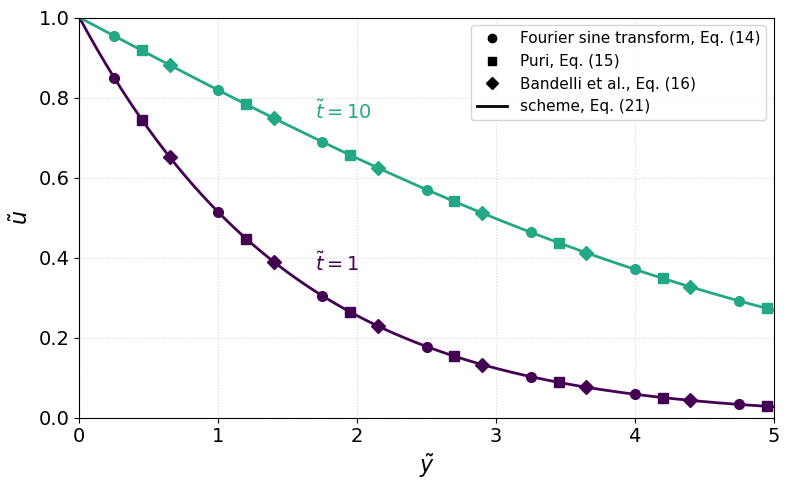

In [12]:
# Fig. 1 of Christov (2010)
times = [1.0, 10.0]
cmap = colormaps['viridis']
y_line = np.linspace(0, 5, 400)
fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
for k in range(len(times)):
    t = times[k]
    color = cmap(0.6*k/(len(times) - 1))
    y_fd, u_fd = sg_fd(1.0, 1.0, t, M=5000, K=5000)
    ax.plot(y_line, np.interp(y_line, y_fd, u_fd), color=color, linewidth=2)
    y_circles = np.linspace(0.25, 4.75, 7)
    y_squares = y_circles + 0.2
    y_diamonds = y_circles + 0.4
    ax.plot(y_circles, profile(unsteadyv, y_circles, t), 'o', color=color, markersize=7)
    ax.plot(y_squares, profile(puri_15, y_squares, t), 's', color=color, markersize=7)
    ax.plot(y_diamonds, profile(bandelli_16, y_diamonds, t), 'D', color=color, markersize=7)
    ax.annotate(rf'$\tilde t = {t:g}$', xy=(1.7, np.interp(1.7, y_fd, u_fd) + 0.05), color=color, fontsize=14)

# legend entries for the methods, in black
ax.plot([], [], 'o', color='black', label='Fourier sine transform, Eq. (14)')
ax.plot([], [], 's', color='black', label='Puri, Eq. (15)')
ax.plot([], [], 'D', color='black', label='Bandelli et al., Eq. (16)')
ax.plot([], [], color='black', linewidth=2, label='scheme, Eq. (21)')
ax.set_xlabel(r'$\tilde y$')
ax.set_ylabel(r'$\tilde u$')
ax.set_xlim(0, 5)
ax.set_ylim(0, 1)
ax.grid(alpha=0.5, linestyle='dotted')
ax.legend(loc='upper right', fontsize=11)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/christov_2010_fig1.png', dpi=200, bbox_inches='tight')

In the variables $\tilde t = t\nu/\alpha$, $\tilde y = y/\sqrt{\alpha}$, $\tilde u = u/U_0$, the equation of motion becomes
$$
    \frac{\partial\tilde u}{\partial\tilde t} = \frac{\partial^2\tilde u}{\partial\tilde y^2} + \frac{\partial^3\tilde u}{\partial\tilde y^2\partial\tilde t},
$$
with no parameters left: $\sqrt{\alpha}$ sets the length (the thickness of the start-up jump) and $\alpha/\nu$ the time. So Fig. 1, drawn for $\nu = \alpha = U_0 = 1$, is the solution for every second-grade fluid. It is not, however, self-similar in the Newtonian sense: the Newtonian solution depends on $y$ and $t$ only through $y/\sqrt{\nu t}$, while here the retardation timescale $\alpha/\nu$ is a second scale, which is why the two curves of Fig. 1 differ in shape and not just in width.

# EXPLORE IT YOURSELF

In [13]:
# Eq. (14) of Christov (2010) and Eq. (2.6) of Fetecau & Zierep (2001): plot function
def plot_func(t):
    y = np.linspace(0, 5, 101)         # fine grid for the envelope
    y_arrows = np.linspace(0, 5, 16)   # about 15 arrows, one at the wall
    u = profile(unsteadyv, y, t)
    # Eq. (2.6) is discontinuous at the wall, so it is drawn from the first grid point off it,
    # where it is already at its limit 1 - exp(-t~), and not from its value at y = 0
    u_wrong = profile(wrong_fetecau_zierep_26, y[1:], t)

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel(r'$\tilde y$')
    ax.set_ylim(0, 5)
    ax.set_xlabel(r'$\tilde u$')
    ax.set_xlim(0, 1.1)
    ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label=rf'correct, $\tilde t={t:.2f}$')
    ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax.plot(u_wrong, y[1:], color='#D55E00', linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (2.6)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.5, linestyle='dotted')
    plt.show()

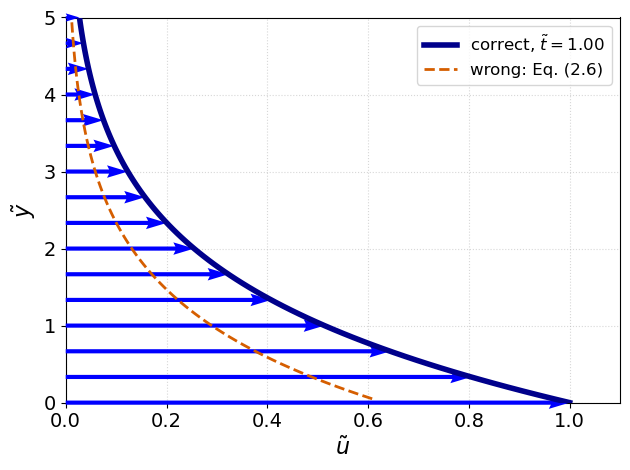

In [14]:
# Eq. (14) of Christov (2010) and Eq. (2.6) of Fetecau & Zierep (2001): static plot (the animation below is stripped in the GitHub preview)
plot_func(1.0)

In [15]:
# Eq. (14) of Christov (2010) and Eq. (2.6) of Fetecau & Zierep (2001): animation
# number of animation frames, and the time of the first one, as `animate' computes it below
numframes = 40
tmax = 10.0
# the first frame; the time steps as the square of the counter
t0 = tmax/numframes**2
y = np.linspace(0, 5, 101)         # fine grid for the envelope
y_arrows = np.linspace(0, 5, 16)   # about 15 arrows, one at the wall
u = profile(unsteadyv, y, t0)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel(r'$\tilde y$')
ax.set_ylim(0, 5)
ax.set_xlabel(r'$\tilde u$')
ax.set_xlim(0, 1.1)
ax.grid(alpha=0.5, linestyle='dotted')
plt.close()

line, = ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label='correct')
# Eq. (2.6) is discontinuous at the wall, so it is drawn from the first grid point off it
line_wrong, = ax.plot(profile(wrong_fetecau_zierep_26, y[1:], t0), y[1:], color='#D55E00',
                      linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (2.6)')
quiv = ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
ax.legend(loc='upper right')

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    # the i passed is the frame counter; squaring it keeps the front, which spreads like
    # sqrt(t~), moving evenly and puts frames at the early times, where the start-up jump is
    tstar = ((i + 1)/numframes)**2*tmax
    u = profile(unsteadyv, y, tstar)
    line.set_data(u, y)
    line_wrong.set_data(profile(wrong_fetecau_zierep_26, y[1:], tstar), y[1:])
    quiv.set_UVC(np.interp(y_arrows, y, u), 0*y_arrows)
    line.set_label(rf'correct, $\tilde t={tstar:.3g}$')
    legend = ax.legend(loc='upper right')
    return (line, line_wrong, quiv, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=150, blit=True, repeat=False)

In [16]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [17]:
# To save the animation, use something like
# anim.save('christov_2010_second_grade.mp4')

# WHAT PROBLEM DOES THE WRONG SOLUTION ACTUALLY SOLVE?

Dropping $U_0\delta(t)$ removes the factor $(\nu+\alpha s)/\nu$ from the transform of the solution, so the erroneous Eq. (2.6) is the solution of the IBVP (13) with the plate ramped on the retardation timescale (that is, $\alpha/\nu$),
$$
    u(0,t) = \left(1 - \mathrm{e}^{-\nu t/\alpha}\right)U_0 H(t),\qquad \bar{u}_\mathrm{wrong}(y,s) = \frac{\nu}{\nu + \alpha s}\,\bar{u}(y,s),
$$
as noted by Christov & Christov (2010). The next cell compares Eq. (2.6) with the de Hoog inversion of $\bar{u}/(1+s)$ ($\nu = \alpha = 1$); the difference should be at the quadrature tolerance.

In [18]:
# Eq. (2.6) of Fetecau & Zierep (2001) versus the ramped-plate solution, inverse of ubar/(1 + s) with nu = alpha = 1
y = np.linspace(0.05, 5, 30)
max_difference = 0.0
for t in [1.0, 10.0]:
    u_ramp = np.zeros_like(y)
    for j in range(len(y)):
        u_ramp[j] = float(mp.invertlaplace(lambda s: ubar_mp(s, y[j])/(1 + s), t, method='dehoog'))
    max_difference = max(max_difference, np.abs(profile(wrong_fetecau_zierep_26, y, t) - u_ramp).max())
print(f'max|Eq. (2.6) - ramped-plate solution| = {max_difference:.1e}')

max|Eq. (2.6) - ramped-plate solution| = 2.2e-10


# ON YOUR OWN

On your own:

*   Plot the three representations at $\tilde t = 10^{-3}$ and find which one is the easiest to evaluate at small times.
*   Evaluate Eq. (15) at $\tilde t \to 0^+$ and compare with the start-up jump $\mathrm{e}^{-\tilde y}$.
*   Change $\mathfrak{u}_0^0$ from $0$ to $U_0$ in `sg_fd` (the argument `v00`) and explain which solution the scheme then converges to.

# REFERENCES

R. Bandelli, K. R. Rajagopal, G. P. Galdi, On some unsteady motions of fluids of second grade, _Arch. Mech._ **47** (1995) 661&ndash;676.

I. C. Christov, Stokes' first problem for some non-Newtonian fluids: Results and mistakes, _Mech. Res. Commun._ **37** (2010) 717&ndash;723. [doi:10.1016/j.mechrescom.2010.09.006](https://doi.org/10.1016/j.mechrescom.2010.09.006); [arXiv:1009.4416](https://arxiv.org/abs/1009.4416)

I. C. Christov, C. I. Christov, Comment on &ldquo;On a class of exact solutions of the equations of motion of a second grade fluid&rdquo; by C. Fetec&#259;u and J. Zierep (Acta Mech. 150, 135&ndash;138, 2001), _Acta Mech._ **215** (2010) 25&ndash;28. [doi:10.1007/s00707-010-0300-2](https://doi.org/10.1007/s00707-010-0300-2); [arXiv:1003.2188](https://arxiv.org/abs/1003.2188)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

P. M. Jordan, Comments on: &ldquo;Exact solution of Stokes' first problem for heated generalized Burgers' fluid in a porous half-space&rdquo; [Nonlinear Anal. RWA 9 (2008) 1628], _Nonlinear Anal. Real World Appl._ **11** (2010) 1198&ndash;1200. [doi:10.1016/j.nonrwa.2009.01.010](https://doi.org/10.1016/j.nonrwa.2009.01.010)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

J. A. Morrison, Wave propagation in rods of Voigt material and visco-elastic materials with three-parameter models, _Quart. Appl. Math._ **14** (1956) 153&ndash;169. [doi:10.1090/qam/78848](https://doi.org/10.1090/qam/78848)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

P. Puri, Impulsive motion of a flat plate in a Rivlin&ndash;Ericksen fluid, _Rheol. Acta_ **23** (1984) 451&ndash;453. [doi:10.1007/BF01329198](https://doi.org/10.1007/BF01329198)

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)